# **LIBRARY**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import pickle

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

### **LOAD DATASET**

In [3]:
df = pd.read_csv("synthetic_timeseries_daily.csv")

df.head()

,user_id,day,work_hours_per_day,sleep_hours,burnout_score,burnout_level,consecutive_overwork,anchor_level
0,user_0000,1,14,6,70,High,1,High
1,user_0000,2,13,6,70,High,2,High
2,user_0000,3,13,6,80,High,3,High
3,user_0000,4,14,5,80,High,4,High
4,user_0000,5,14,5,80,High,5,High


### **FEATURE ENGINEERING**

In [4]:
# Sorting data
df = df.sort_values(["user_id", "day"]).reset_index(drop=True)

# Sleep work ratio (untuk melihat keseimbangan antara waktu tidur dan jam kerja)
df["sleep_work_ratio"] = df["sleep_hours"] / (df["work_hours_per_day"] + 1e-6)

# Rolling Mean dan Rolling Standard Deviation
df["burnout_rolling_mean_7"] = (
    df.groupby("user_id")["burnout_score"]
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

df["burnout_rolling_mean_14"] = (
    df.groupby("user_id")["burnout_score"]
    .rolling(14)
    .mean()
    .reset_index(level=0, drop=True)
)

df["burnout_rolling_std_7"] = (
    df.groupby("user_id")["burnout_score"]
    .rolling(7)
    .std()
    .reset_index(level=0, drop=True)
)

df["work_rolling_mean_7"] = (
    df.groupby("user_id")["work_hours_per_day"]
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

df["sleep_rolling_mean_7"] = (
    df.groupby("user_id")["sleep_hours"]
    .rolling(7)
    .mean()
    .reset_index(level=0, drop=True)
)

df = df.dropna().reset_index(drop=True)

### **FEATURE SELECTION**

In [5]:
features = [
    "work_hours_per_day",
    "sleep_hours",
    "consecutive_overwork",
    "sleep_work_ratio",
    "burnout_rolling_mean_7",
    "burnout_rolling_mean_14",
    "burnout_rolling_std_7",
    "work_rolling_mean_7",
    "sleep_rolling_mean_7"
]

target = "burnout_score"

WINDOW_SIZE = 7

### **SEQUENCE CREATION**
Model menggunakan pendekatan sequence/time-series dengan membaca data aktivitas 7 hari sebelumnya untuk memprediksi burnout score hari berikutnya

In [6]:
def create_sequences(df, features, target, window_size=7):
    X, y = [], []

    for user_id, user_data in df.groupby("user_id"):
        user_data = user_data.sort_values("day")

        feature_values = user_data[features].values
        target_values = user_data[target].values

        for i in range(len(user_data) - window_size):
            X.append(feature_values[i:i + window_size])
            y.append(target_values[i + window_size])

    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

In [7]:
X, y = create_sequences(
    df=df,
    features=features,
    target=target,
    window_size=WINDOW_SIZE
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10650, 7, 9)
y shape: (10650,)


### **SPLITING DATA**

In [8]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    shuffle=False
)

print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)

X_train: (8520, 7, 9)
X_val  : (1065, 7, 9)
X_test : (1065, 7, 9)


### **FEATURE SCALING**

In [9]:
feature_scaler = MinMaxScaler()
target_scaler = MinMaxScaler()

n_features = X_train.shape[2]

X_train_2d = X_train.reshape(-1, n_features)
X_val_2d = X_val.reshape(-1, n_features)
X_test_2d = X_test.reshape(-1, n_features)

X_train = feature_scaler.fit_transform(X_train_2d).reshape(X_train.shape)
X_val = feature_scaler.transform(X_val_2d).reshape(X_val.shape)
X_test = feature_scaler.transform(X_test_2d).reshape(X_test.shape)

y_train = target_scaler.fit_transform(y_train.reshape(-1, 1))
y_val = target_scaler.transform(y_val.reshape(-1, 1))
y_test = target_scaler.transform(y_test.reshape(-1, 1))

### **SAVE SCALER**

In [10]:
with open("feature_scaler.pkl", "wb") as f:
    pickle.dump(feature_scaler, f)

with open("target_scaler.pkl", "wb") as f:
    pickle.dump(target_scaler, f)

### **TENSORFLOW DATASET PIPELINE**

In [11]:
BATCH_SIZE = 32

# Dataset diubah menjadi TensorFlow Dataset
train_dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train))
train_dataset = train_dataset.shuffle(2000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_dataset = tf.data.Dataset.from_tensor_slices((X_val, y_val))
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

test_dataset = tf.data.Dataset.from_tensor_slices((X_test, y_test))
test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

### **ATTENTION LAYER**
Digunakan `TemporalAttention` agar model dapat fokus pada hari tertentu yang paling penting dan memberikan bobot lebih besar pada pola aktivitas signifikan. 

In [12]:
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self, units=32, **kwargs):
        super(TemporalAttention, self).__init__(**kwargs)
        self.units = units
        self.W = tf.keras.layers.Dense(units)
        self.V = tf.keras.layers.Dense(1)

    def call(self, inputs):
        score = self.V(tf.nn.tanh(self.W(inputs)))
        attention_weights = tf.nn.softmax(score, axis=1)

        context_vector = attention_weights * inputs
        context_vector = tf.reduce_sum(context_vector, axis=1)

        return context_vector

    def get_config(self):
        config = super().get_config()
        config.update({
            "units": self.units
        })
        return config

### **MODEL ARCHITECTURE**
`Input Layer` -> `GRU` -> `Attention Layer` -> `Layer Normalization` -> `Dense Layer` -> `Output Layer`

In [13]:
input_layer = tf.keras.Input(
    shape=(WINDOW_SIZE, len(features)),
    name="burnout_sequence_input"
)

x = tf.keras.layers.GRU(
    64,
    return_sequences=True,
    dropout=0.1,
    recurrent_dropout=0.05,
    kernel_regularizer=tf.keras.regularizers.l2(1e-5),
    name="gru_1"
)(input_layer)

x = TemporalAttention(units=32)(x)

x = tf.keras.layers.LayerNormalization()(x)

x = tf.keras.layers.Dense(
    32,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-5)
)(x)

x = tf.keras.layers.Dropout(0.1)(x)

x = tf.keras.layers.Dense(
    16,
    activation="relu",
    kernel_regularizer=tf.keras.regularizers.l2(1e-5)
)(x)

output_layer = tf.keras.layers.Dense(
    1,
    activation="sigmoid",
    name="burnout_score_output"
)(x)

model = tf.keras.Model(
    inputs=input_layer,
    outputs=output_layer
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ burnout_sequence_input          │ (None, 7, 9)           │             0 │
│ (InputLayer)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 7, 64)          │        14,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ temporal_attention              │ (None, 64)             │         2,113 │
│ (TemporalAttention)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization             │ (None, 64)             │           128 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ burnout_score_output (Dense)    │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,266 (75.26 KB)

 Trainable params: 19,266 (75.26 KB)

 Non-trainable params: 0 (0.00 B)

### **OPTIMIZER & LOSS FUNCTION**

In [14]:
# Digunakan optimizer adam
optimizer = tf.keras.optimizers.Adam(
    learning_rate=0.0003,
    clipnorm=1.0
)

# Loss Function menggunakan MAE agar fokus pada besar selisih prediksi terhadap nilai aktual
loss_fn = tf.keras.losses.MeanAbsoluteError()

train_loss_metric = tf.keras.metrics.Mean(name="train_loss")
train_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="train_mae")

val_loss_metric = tf.keras.metrics.Mean(name="val_loss")
val_mae_metric = tf.keras.metrics.MeanAbsoluteError(name="val_mae")

### **CUSTOM TRAINING LOOP**

In [15]:
@tf.function
def train_step(x_batch, y_batch):
    with tf.GradientTape() as tape:
        predictions = model(x_batch, training=True)
        loss = loss_fn(y_batch, predictions)

    gradients = tape.gradient(loss, model.trainable_variables)

    optimizer.apply_gradients(
        zip(gradients, model.trainable_variables)
    )

    train_loss_metric.update_state(loss)
    train_mae_metric.update_state(y_batch, predictions)

    return loss

In [16]:
@tf.function
def val_step(x_batch, y_batch):
    predictions = model(x_batch, training=False)
    loss = loss_fn(y_batch, predictions)

    val_loss_metric.update_state(loss)
    val_mae_metric.update_state(y_batch, predictions)

    return loss

### **TRAINING MODEL**

In [17]:
# Digunakan Early Stopping dan Learning Rate Scheduler
EPOCHS = 100
PATIENCE = 10       # early stop jika validation MAE tidak membaik selama 10 epoch

best_val_mae = np.inf
wait = 0
lr_wait = 0

history = {
    "train_loss": [],
    "train_mae": [],
    "val_loss": [],
    "val_mae": []
}

for epoch in range(EPOCHS):
    train_loss_metric.reset_state()
    train_mae_metric.reset_state()
    val_loss_metric.reset_state()
    val_mae_metric.reset_state()

    for x_batch, y_batch in train_dataset:
        train_step(x_batch, y_batch)

    for x_batch, y_batch in val_dataset:
        val_step(x_batch, y_batch)

    train_loss = train_loss_metric.result().numpy()
    train_mae = train_mae_metric.result().numpy()
    val_loss = val_loss_metric.result().numpy()
    val_mae = val_mae_metric.result().numpy()

    history["train_loss"].append(train_loss)
    history["train_mae"].append(train_mae)
    history["val_loss"].append(val_loss)
    history["val_mae"].append(val_mae)

    print(
        f"epoch {epoch + 1} | "
        f"train loss: {train_loss:.4f} - "
        f"train mae: {train_mae:.4f} | "
        f"val loss: {val_loss:.4f} - "
        f"val mae: {val_mae:.4f}"
    )

    if val_mae < best_val_mae:
        best_val_mae = val_mae
        wait = 0
        lr_wait = 0

        model.save("best_burnout_model.keras")
        print("best model saved")

    else:
        wait += 1
        lr_wait += 1

        # Learning Rate Reduction
        if lr_wait >= 6:
            new_lr = optimizer.learning_rate * 0.7
            optimizer.learning_rate.assign(new_lr)
            print(f"Learning rate reduced to {optimizer.learning_rate.numpy()}")
            
            lr_wait = 0

    if wait >= PATIENCE:
        print("early stopping")
        break

print("Best Val MAE:", best_val_mae)

epoch 1 | train loss: 0.1413 - train mae: 0.1416 | val loss: 0.0568 - val mae: 0.0565
best model saved
epoch 2 | train loss: 0.0684 - train mae: 0.0683 | val loss: 0.0441 - val mae: 0.0435
best model saved
epoch 3 | train loss: 0.0517 - train mae: 0.0518 | val loss: 0.0367 - val mae: 0.0360
best model saved
epoch 4 | train loss: 0.0462 - train mae: 0.0462 | val loss: 0.0361 - val mae: 0.0355
best model saved
epoch 5 | train loss: 0.0433 - train mae: 0.0432 | val loss: 0.0283 - val mae: 0.0277
best model saved
epoch 6 | train loss: 0.0401 - train mae: 0.0401 | val loss: 0.0346 - val mae: 0.0346
epoch 7 | train loss: 0.0363 - train mae: 0.0363 | val loss: 0.0264 - val mae: 0.0263
best model saved
epoch 8 | train loss: 0.0358 - train mae: 0.0358 | val loss: 0.0344 - val mae: 0.0347
epoch 9 | train loss: 0.0332 - train mae: 0.0333 | val loss: 0.0254 - val mae: 0.0256
best model saved
epoch 10 | train loss: 0.0330 - train mae: 0.0330 | val loss: 0.0295 - val mae: 0.0297
epoch 11 | train los

### **SAVE BEST MODEL**

In [18]:
best_model = tf.keras.models.load_model(
    "best_burnout_model.keras",
    custom_objects = {
    "TemporalAttention": TemporalAttention
    }
)

c:\Users\snsv\Documents\Capstone Project_LSTM\myenv\lib\site-packages\keras\src\layers\layer.py:421: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


### **MODEL EVALUATION**

In [19]:
y_pred_scaled = best_model.predict(X_test)

mae_scaled = mean_absolute_error(y_test, y_pred_scaled)
accuracy_scaled = (1 - mae_scaled) * 100

print("MAE scaled:", mae_scaled)
print("Accuracy scaled:", accuracy_scaled)

y_test_ori = target_scaler.inverse_transform(y_test)
y_pred_ori = target_scaler.inverse_transform(y_pred_scaled)

mae = mean_absolute_error(y_test_ori, y_pred_ori)
mse = mean_squared_error(y_test_ori, y_pred_ori)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_ori, y_pred_ori)

print("MAE original:", mae)
print("MSE original:", mse)
print("RMSE original:", rmse)
print("R2:", r2)

34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
MAE scaled: 0.026059439405798912
Accuracy scaled: 97.39405605942011
MAE original: 2.3453497886657715
MSE original: 15.007841110229492
RMSE original: 3.873995496929429
R2: 0.9867971539497375


In [20]:
mape = np.mean(np.abs((y_test_ori - y_pred_ori) / (y_test_ori + 1e-6))) * 100

print("MAPE", mape)

MAPE 5.9005337


## **VISUALIZATION**

##### **MAPE VISUALIZATION**

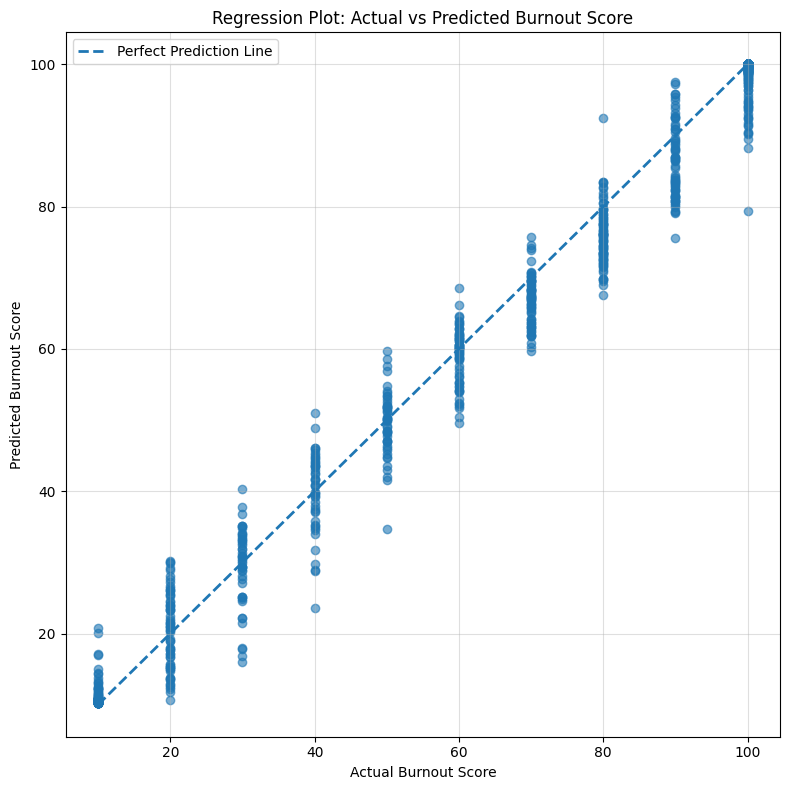

In [24]:
plt.figure(figsize=(8, 8))

plt.scatter(
    y_test_ori,
    y_pred_ori,
    alpha=0.6
)

min_value = min(y_test_ori.min(), y_pred_ori.min())
max_value = max(y_test_ori.max(), y_pred_ori.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction Line"
)

plt.title("Regression Plot: Actual vs Predicted Burnout Score")
plt.xlabel("Actual Burnout Score")
plt.ylabel("Predicted Burnout Score")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### **ACTUAL VS PREDICT BURNOUT SCORE VISUALIZATION**

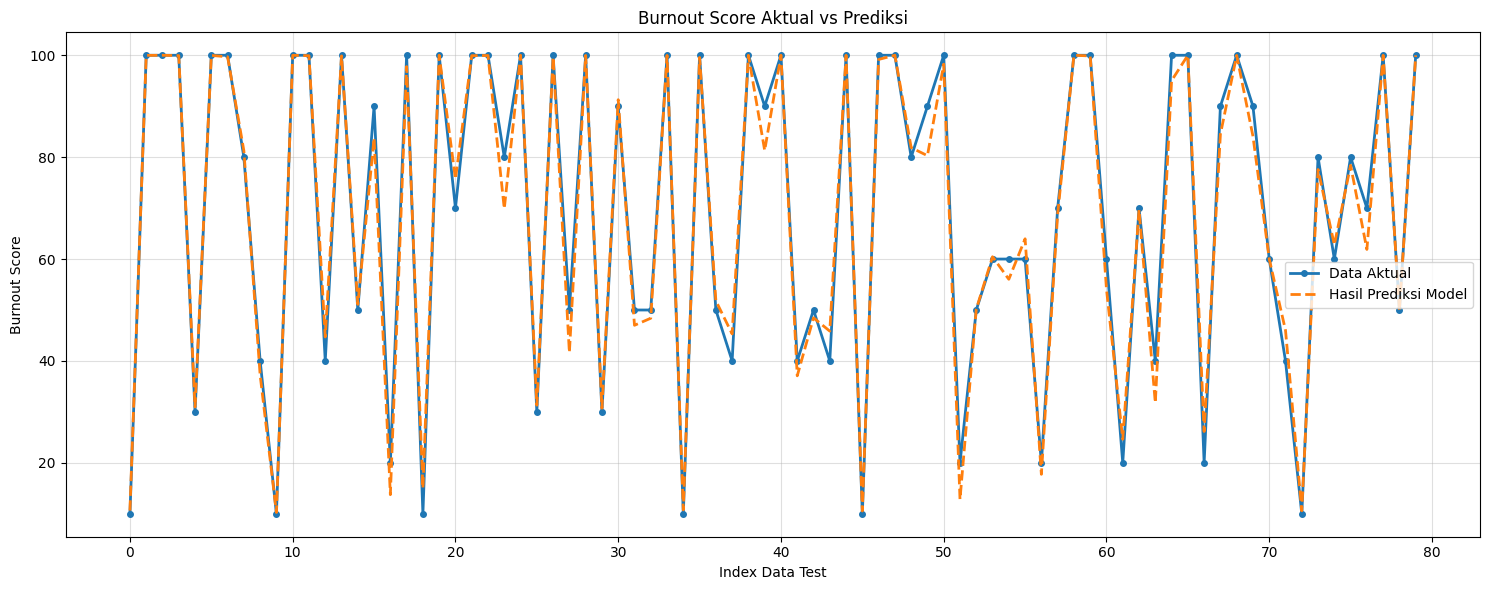

In [25]:
plt.figure(figsize=(15, 6))

plt.plot(
    y_test_ori[:80],
    label="Data Aktual",
    linewidth=2,
    marker="o",
    markersize=4
)

plt.plot(
    y_pred_ori[:80],
    label="Hasil Prediksi Model",
    linestyle="--",
    linewidth=2
)

plt.title("Burnout Score Aktual vs Prediksi")
plt.xlabel("Index Data Test")
plt.ylabel("Burnout Score")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

##### **TRAIN VS VALIDATION MAE VISUALIZATION**

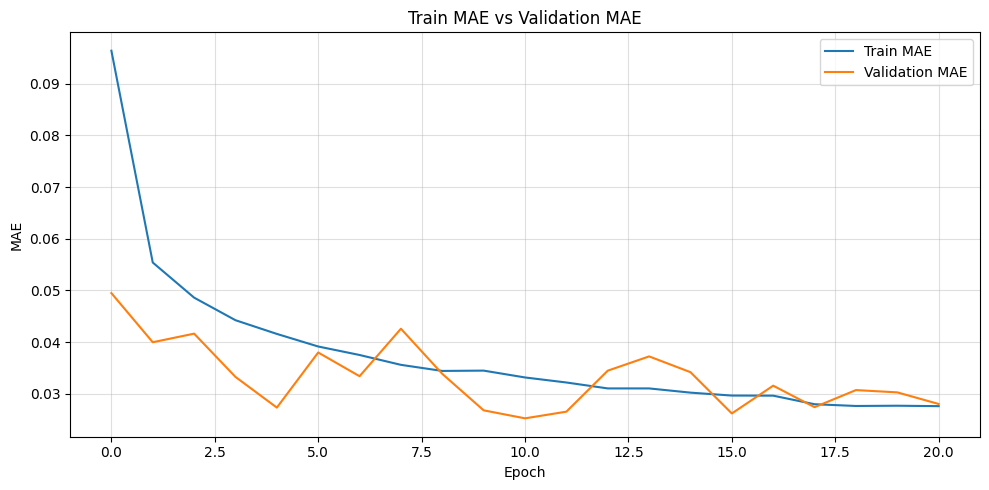

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(history["train_mae"], label="Train MAE")
plt.plot(history["val_mae"], label="Validation MAE")

plt.title("Train MAE vs Validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.legend()
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

### **BURNOUT LEVEL CLASSIFICATION**

In [ ]:
def get_burnout_level(score):
    if score < 40:
        return "Low"
    elif score < 70:
        return "Moderate"
    else:
        return "High"

### **HYBRID COMBINATION WITH QUESTIONNAIRE**

In [ ]:
def combine_with_questionnaire(predicted_score, questionnaire_score):
    predicted_score = float(predicted_score)
    questionnaire_score = float(questionnaire_score)

    diff = abs(predicted_score - questionnaire_score)

    if diff <= 10:
        final_score = (0.5 * predicted_score) + (0.5 * questionnaire_score)
        weighting_type = "balanced weighting"

    elif diff <= 25:
        final_score = (0.4 * predicted_score) + (0.6 * questionnaire_score)
        weighting_type = "moderate questionnaire priority"

    else:
        final_score = (0.3 * predicted_score) + (0.7 * questionnaire_score)
        weighting_type = "high questionnaire priority"

    final_score = np.clip(final_score, 0, 100)

    return {
        "final_score": round(float(final_score), 2),
        "difference": round(float(diff), 2),
        "weighting_type": weighting_type
    }

### **FINAL PREDICTION FUNCTION**

In [ ]:
def predict_burnout_score_final(
    work_hours_7days,
    sleep_hours_7days,
    consecutive_overwork_7days,
    burnout_score_7days,
    questionnaire_score
):

    if not (len(work_hours_7days) == len(sleep_hours_7days) == len(consecutive_overwork_7days) == len(burnout_score_7days) == 7):
        raise ValueError("Semua input data perilaku harus berisi tepat 7 data (sesuai WINDOW_SIZE)")

    if questionnaire_score < 0 or questionnaire_score > 100:
        raise ValueError("questionnaire_score harus berada pada rentang 0-100")

    with open("feature_scaler.pkl", "rb") as f:
        feature_scaler = pickle.load(f)
    with open("target_scaler.pkl", "rb") as f:
        target_scaler = pickle.load(f)

    df_temp = pd.DataFrame({
        "work_hours_per_day": work_hours_7days,
        "sleep_hours": sleep_hours_7days,
        "consecutive_overwork": consecutive_overwork_7days,
        "burnout_score": burnout_score_7days
    })
    
    df_temp["sleep_work_ratio"] = df_temp["sleep_hours"] / (df_temp["work_hours_per_day"] + 1e-6)

    b_mean = df_temp["burnout_score"].mean()
    b_std = df_temp["burnout_score"].std()
    w_mean = df_temp["work_hours_per_day"].mean()
    s_mean = df_temp["sleep_hours"].mean()

    if np.isnan(b_std):
        b_std = 0.0

    df_temp["burnout_rolling_mean_7"] = b_mean
    df_temp["burnout_rolling_mean_14"] = b_mean 
    df_temp["burnout_rolling_std_7"] = b_std
    df_temp["work_rolling_mean_7"] = w_mean
    df_temp["sleep_rolling_mean_7"] = s_mean

    feature_order = [
        "work_hours_per_day", "sleep_hours", "consecutive_overwork", "sleep_work_ratio",
        "burnout_rolling_mean_7", "burnout_rolling_mean_14",
        "burnout_rolling_std_7", "work_rolling_mean_7", "sleep_rolling_mean_7"
    ]
    
    sequence_input = df_temp[feature_order].values 
    
    sequence_input_scaled = feature_scaler.transform(sequence_input)
    sequence_input_scaled = np.expand_dims(sequence_input_scaled, axis=0)

    pred_scaled = best_model.predict(sequence_input_scaled, verbose=0)
    behavior_score = target_scaler.inverse_transform(pred_scaled)[0][0]
    behavior_score = np.clip(behavior_score, 0, 100)

    combined_result = combine_with_questionnaire(behavior_score, questionnaire_score)

    return {
        "behavior_prediction_score": round(float(behavior_score), 2),
        "questionnaire_score": round(float(questionnaire_score), 2),
        "final_burnout_score": combined_result["final_score"],
        "final_burnout_level": get_burnout_level(combined_result["final_score"]),
        "difference": combined_result["difference"],
        "weighting_type": combined_result["weighting_type"]
    }

### **INFERENCE**

In [ ]:
work_hours_input = [
    10, 11, 10, 12, 11, 10, 11,
    12, 11, 10, 11, 12, 10, 11
]

sleep_hours_input = [
    6, 5, 6, 5, 5, 6, 5,
    5, 6, 5, 5, 5, 6, 5
]

consecutive_input = [
    2, 3, 4, 5, 6, 7, 8,
    9, 10, 11, 12, 13, 14, 15
]

burnout_score_input = [
    45, 50, 48, 52, 55, 53, 56
]

questionnaire_score = 58

result = predict_burnout_score_final(
    work_hours_7days=work_hours_input[-7:],
    sleep_hours_7days=sleep_hours_input[-7:],
    consecutive_overwork_7days=consecutive_input[-7:],
    burnout_score_7days=burnout_score_input,
    questionnaire_score=questionnaire_score
)

print(result)

{'behavior_prediction_score': 69.23, 'questionnaire_score': 58.0, 'final_burnout_score': 62.49, 'final_burnout_level': 'Moderate', 'difference': 11.23, 'weighting_type': 'moderate questionnaire priority'}
